In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data Transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
!pip install escnn

In [3]:
!pip install transformers

In [ ]:
import numpy as np
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_size=(96, 96)):
        self.root_dir = root_dir
        self.transform = transform
        self.target_size = target_size 
        self.image_paths = []
        self.labels = []

        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for class_name, class_idx in self.class_map.items():
            class_folder = os.path.join(root_dir, class_name)
            pattern = os.path.join(class_folder, "*.npy")
            files = glob.glob(pattern)

            # Suppressing print to keep your training logs clean, 
            # but you can uncomment this if you want to verify counts!
            print(f"Found {len(files)} .npy files in: {class_name}")

            for f in files:
                self.image_paths.append(f)
                self.labels.append(class_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load the raw physics data
        img_path = self.image_paths[idx]
        array = np.load(img_path).squeeze()

        # 2. Apply arcsinh stretch (Locked in at factor=10.0 based on your visual check)
        stretch_factor = 10.0 
        array = np.arcsinh(array * stretch_factor) / np.arcsinh(stretch_factor)
        
        # 3. Rescale to 0-255 and convert to PIL
        array = (array * 255).astype(np.uint8)
        image = Image.fromarray(array).convert('RGB')
        
        # 4. Dynamic resize for CNN vs Transformer
        if self.target_size is not None:
            image = image.resize(self.target_size, Image.Resampling.BILINEAR)

        # 5. Apply PyTorch transforms (Augmentations, ToTensor, Normalize)
        if self.transform:
            image = self.transform(image)
            
        label = self.labels[idx]
        return image, label




def get_dataloaders(train_dir, val_dir, target_size=(96, 96), batch_size=128):
    """
    Dynamically creates DataLoaders with the correct image size and VRAM-safe batch sizes.
    """
    
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    # Physics-informed augmentations for training
    train_transforms = transforms.Compose([
        transforms.RandomRotation(180),          # Space has no "up"
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # No augmentations for validation! Just strict formatting.
    val_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # Create Datasets
    train_dataset = LensingDataset(train_dir, transform=train_transforms, target_size=target_size)
    val_dataset = LensingDataset(val_dir, transform=val_transforms, target_size=target_size)

    # Create Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader

In [ ]:
import torch
import escnn.nn as enn
from escnn import gspaces

class EquivariantResidualBlock(torch.nn.Module):
    """A standard ResNet block, but mathematically strictly equivariant."""
    def __init__(self, in_type, out_type, stride=1):
        super().__init__()
        self.in_type = in_type
        self.out_type = out_type
        
        self.conv1 = enn.R2Conv(in_type, out_type, kernel_size=3, padding=1, stride=stride, bias=False)
        self.bn1 = enn.InnerBatchNorm(out_type)
        self.relu1 = enn.ReLU(out_type, inplace=True)
        
        self.conv2 = enn.R2Conv(out_type, out_type, kernel_size=3, padding=1, stride=1, bias=False)
        self.bn2 = enn.InnerBatchNorm(out_type)
        self.relu2 = enn.ReLU(out_type, inplace=True)
        
        # The "Shortcut" connection that makes ResNets work
        self.shortcut = None
        if stride != 1 or in_type != out_type:
            self.shortcut = enn.SequentialModule(
                enn.R2Conv(in_type, out_type, kernel_size=1, stride=stride, bias=False),
                enn.InnerBatchNorm(out_type)
            )

    def forward(self, x):
        identity = x if self.shortcut is None else self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add the residual skip connection
        out = out + identity
        out = self.relu2(out)
        return out

class EquivariantResNet(torch.nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        # C4 Symmetry (0, 90, 180, 270 degrees)
        self.r2_act = gspaces.rot2dOnR2(N=4)
        
        # Define the math types
        in_type = enn.FieldType(self.r2_act, 3 * [self.r2_act.trivial_repr])
        type_16 = enn.FieldType(self.r2_act, 16 * [self.r2_act.regular_repr])
        type_32 = enn.FieldType(self.r2_act, 32 * [self.r2_act.regular_repr])
        type_64 = enn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        
        # Initial Convolution (Entry to the network)
        self.conv1 = enn.SequentialModule(
            enn.R2Conv(in_type, type_16, kernel_size=5, padding=2, stride=2, bias=False),
            enn.InnerBatchNorm(type_16),
            enn.ReLU(type_16, inplace=True)
        )
        
        # ResNet Stages (Increasing depth and receptive field)
        self.layer1 = EquivariantResidualBlock(type_16, type_16, stride=1)
        self.layer2 = EquivariantResidualBlock(type_16, type_32, stride=2)
        self.layer3 = EquivariantResidualBlock(type_32, type_64, stride=2)
        
        # Collapse the rotational features
        self.gpool = enn.GroupPooling(type_64)
        
        # Final classification
        self.fc = torch.nn.Sequential(
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.conv1.in_type)
        
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gpool(x)
        
        x = x.tensor
        x = self.fc(x)
        return x

def build_equivariant_cnn():
    return EquivariantResNet(num_classes=3)

In [6]:
!pip install scikit-learn

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import copy 

def count_parameters(model, print_out=True):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if print_out:
        print(f"-> Trainable Parameters: {trainable_params:,}")
    return trainable_params

class ExperimentTracker:
    def __init__(self, num_classes=3, device=None, save_dir="saved_weights"):
        self.num_classes = num_classes
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.results = {}
        self.class_names = {0: 'No Substructure', 1: 'Sphere', 2: 'Vortex'}
        
        # UPGRADE 5: Set up directory for saving weights
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)
        
        # Track the absolute best model across all experiments
        self.global_best_macro_auc = -1.0
        self.global_best_model_name = ""

    def _run_epoch(self, model, loader, criterion, optimizer=None):
        is_train = optimizer is not None
        model.train() if is_train else model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(loader, unit="batch", leave=False)

        with torch.set_grad_enabled(is_train):
            for inputs, labels in pbar:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                if is_train:
                    optimizer.zero_grad()

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                if is_train:
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                mode = "Train" if is_train else "Val"
                pbar.set_description(f"{mode}")
                pbar.set_postfix(loss=loss.item(), acc=100.*correct/total)

        return running_loss / len(loader), 100. * correct / total

    # UPGRADE 6: Added 'model_name' to save individual weights
    def train_model(self, model, model_name, train_loader, val_loader, epochs=15, lr=0.0001, patience=4):
        model = model.to(self.device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(model.state_dict())

        for epoch in range(epochs):
            print(f"\n--- Epoch {epoch+1}/{epochs} ---")
            train_loss, train_acc = self._run_epoch(model, train_loader, criterion, optimizer)
            val_loss, val_acc = self._run_epoch(model, val_loader, criterion)
            
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                print(f"-> No improvement in Val Loss. Early Stopping counter: {epochs_no_improve}/{patience}")

            if epochs_no_improve >= patience:
                print(f"\n*** Early stopping triggered at epoch {epoch+1} ***")
                break
                
        print(f"-> Loading best model weights for {model_name} (based on Val Loss).")
        model.load_state_dict(best_model_wts)
        
        # Save this specific model's weights
        safe_name = model_name.replace(" ", "_").replace("/", "-")
        save_path = os.path.join(self.save_dir, f"{safe_name}_best.pth")
        torch.save(model.state_dict(), save_path)
        print(f"-> Saved {model_name} weights to: {save_path}")
        
        return model, history

    def evaluate_auc(self, model, val_loader):
        model.eval()
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(self.device)
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1).cpu().numpy()
                
                all_probs.extend(probs)
                all_labels.extend(labels.numpy())

        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)

        auc_per_class = roc_auc_score(all_labels, all_probs, multi_class='ovr', average=None)
        macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

        return auc_per_class, macro_auc, all_labels, all_probs

    def compare_models(self, model_configs, patience=3):
        for name, config in model_configs.items():
            print(f"\n=========================================")
            print(f" Evaluating Model: {name}")
            print(f"=========================================")
            
            model_builder = config['builder']
            m_epochs = config['epochs']
            m_lr = config['lr']
            m_train_loader = config['train_loader']
            m_val_loader = config['val_loader']

            model = model_builder() 
            params = count_parameters(model)
            
            print(f"-> Custom Config - Target Epochs: {m_epochs} | Learning Rate: {m_lr}")
            
            # Pass 'name' into train_model for file saving
            trained_model, history = self.train_model(
                model, name, m_train_loader, m_val_loader, epochs=m_epochs, lr=m_lr, patience=patience
            )
            auc_per_class, macro_auc, y_true, y_probs = self.evaluate_auc(trained_model, m_val_loader)
            
            self.results[name] = {
                'params': params,
                'history': history,
                'auc_per_class': auc_per_class,
                'macro_auc': macro_auc,
                'y_true': y_true,
                'y_probs': y_probs
            }
            
            print(f"\n>>> Final Results for {name}:")
            print(f"Class-wise AUC: {auc_per_class}")
            print(f"Macro Average AUC: {macro_auc:.4f}")
            
            # UPGRADE 7: Check and save the global champion model
            if macro_auc > self.global_best_macro_auc:
                self.global_best_macro_auc = macro_auc
                self.global_best_model_name = name
                global_save_path = os.path.join(self.save_dir, "OVERALL_BEST_MODEL.pth")
                torch.save(trained_model.state_dict(), global_save_path)
                print(f"*** NEW GLOBAL CHAMPION! {name} saved as OVERALL_BEST_MODEL.pth (Macro AUC: {macro_auc:.4f}) ***")

    def plot_loss_curves(self):
        if not self.results: return
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        for name, data in self.results.items():
            history = data['history']
            epochs = range(1, len(history['train_loss']) + 1)
            axes[0].plot(epochs, history['train_loss'], marker='o', label=name)
            axes[1].plot(epochs, history['val_loss'], marker='o', label=name)
            
        axes[0].set_title('Training Loss per Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Cross Entropy Loss')
        axes[0].grid(True, linestyle='--', alpha=0.6)
        axes[0].legend()
        
        axes[1].set_title('Validation Loss per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Cross Entropy Loss')
        axes[1].grid(True, linestyle='--', alpha=0.6)
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    def plot_roc_curves(self):
        if not self.results: return
        fig, axes = plt.subplots(1, self.num_classes, figsize=(18, 5))
        for class_idx in range(self.num_classes):
            ax = axes[class_idx]
            class_name = self.class_names.get(class_idx, f'Class {class_idx}')
            for name, data in self.results.items():
                y_true_binary = (data['y_true'] == class_idx).astype(int)
                y_probs_class = data['y_probs'][:, class_idx]
                fpr, tpr, _ = roc_curve(y_true_binary, y_probs_class)
                auc_score = data['auc_per_class'][class_idx]
                ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')
            ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
            ax.set_title(f'ROC: {class_name} vs Rest')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    def plot_parameter_counts(self):
        if not self.results: return
        names = list(self.results.keys())
        params = [self.results[name]['params'] for name in names]
        plt.figure(figsize=(10, 6))
        bars = plt.bar(names, params, color='coral', edgecolor='black', alpha=0.8)
        plt.title('Trainable Parameters per Model Architecture', fontsize=14, fontweight='bold')
        plt.ylabel('Number of Parameters (Millions)', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        for bar in bars:
            yval = bar.get_height()
            label_text = f'{yval / 1e6:.1f}M' if yval >= 1e6 else f'{yval:,}'
            plt.text(bar.get_x() + bar.get_width()/2, yval, label_text, ha='center', va='bottom', fontweight='bold')
        plt.tight_layout()
        plt.show()

In [ ]:
import timm
import torch.nn as nn

# 1. Standard Vision Transformer (ViT)
def build_vit_base():
    # 'vit_base_patch16_224' expects 224x224 images
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=3)
    return model

# 2. Convolutional Vision Transformer (CvT)
def build_cvt_13():
    # CvT is a fantastic hybrid. 'cvt_13' is the lightweight 13-layer version.
    # It handles varying resolutions much better than standard ViT.
    model = timm.create_model('cvt_13', pretrained=True, num_classes=3)
    return model
    

def build_convnext_tiny():
    """
    Builds a ConvNeXt-Tiny model.
    Using timm makes it incredibly easy: setting num_classes=3 
    automatically drops the original 1000-class ImageNet head 
    and replaces it with a fresh 3-class linear layer for our dataset.
    """
    model = timm.create_model('convnext_tiny', pretrained=True, num_classes=3)
    return model

def build_resnet50():
    model = models.resnet50(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, 3)
    return model


In [9]:
from transformers import CvtForImageClassification
import torch.nn as nn

class CvTWrapper(nn.Module):
    def __init__(self):
        super().__init__()
        # Load the pre-trained CvT model directly from Microsoft's Hugging Face repo
        # ignore_mismatched_sizes=True automatically strips the 1000-class ImageNet 
        # head and replaces it with our custom 3-class head.
        self.cvt = CvtForImageClassification.from_pretrained(
            'microsoft/cvt-13', 
            num_labels=3, 
            ignore_mismatched_sizes=True
        )
        
    def forward(self, x):
        # Hugging Face models return an output object. 
        # Our training loop just needs the raw tensor math (logits).
        return self.cvt(x).logits

def build_cvt_13():
    return CvTWrapper()

In [ ]:
# 1. Create the two different sets of DataLoaders
train_dir = '/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train'
val_dir = '/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/val'

cnn_train, cnn_val = get_dataloaders(train_dir, val_dir, target_size=(96, 96), batch_size=128)
vit_train, vit_val = get_dataloaders(train_dir, val_dir, target_size=(224, 224), batch_size=32)




master_configs1 = {
    # --- CNNs (Fast LR, 96x96 Loaders) ---
    "ResNet-50": {
        "builder": build_resnet50,
        "epochs": 25,
        "lr": 0.0001,
        "optimizer": "Adam",
        "weight_decay": 1e-4,
        "train_loader": cnn_train,
        "val_loader": cnn_val
    }
     ,
    "E(2)-Steerable CNN": {                
        "builder": build_equivariant_cnn,
        "epochs": 40, 
        "lr": 0.0001,           
        "optimizer": "Adam",
        "weight_decay": 1e-3,
        "train_loader": cnn_train, 
        "val_loader": cnn_val
    },
    
     "ConvNeXt-Tiny": {
        "builder": build_convnext_tiny,
        "epochs": 25,
        "lr": 0.00005,          # Lower LR for ConvNeXt prevents 33% collapse
        "optimizer": "AdamW",   # AdamW is mandatory for ConvNeXt
        "weight_decay": 1e-2,   # High weight decay stabilizes feature extractors
        "train_loader": cnn_train,
        "val_loader": cnn_val
    }
}
    



master_configs2 = {

      "CvT-13": {
        "builder": build_cvt_13, 
        "epochs": 20,       
        "lr": 0.00005,  
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "train_loader": vit_train,
        "val_loader": vit_val
     },
    "ViT-Base": {
        "builder": build_vit_base, 
        "epochs": 20,       
        "lr": 0.00003,          # ViTs need a very low learning rate
        "optimizer": "AdamW",   # AdamW is mandatory for Transformers
        "weight_decay": 0.01,
        "train_loader": vit_train,
        "val_loader": vit_val
    }
 
 
}


Found 10000 .npy files in: no
Found 10000 .npy files in: sphere
Found 10000 .npy files in: vort
Found 2500 .npy files in: no
Found 2500 .npy files in: sphere
Found 2500 .npy files in: vort
Found 10000 .npy files in: no
Found 10000 .npy files in: sphere
Found 10000 .npy files in: vort
Found 2500 .npy files in: no
Found 2500 .npy files in: sphere
Found 2500 .npy files in: vort


In [ ]:
# 3. Initialize ONE Tracker and run the Master Config
print("\n" + "="*60)
print(">>> COMMENCING ALL Convolution modelsIN-ONE GRAND EXPERIMENT <<<")
print("="*60)


master_tracker = ExperimentTracker(num_classes=3)
master_tracker.compare_models(master_configs1, patience=3)

# 4. Generate the Unified Master Plots
print("\nGenerating Unified Master Plots...")
master_tracker.plot_parameter_counts()
master_tracker.plot_loss_curves()
master_tracker.plot_roc_curves()


 Evaluating Model: CvT-13


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([3, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


...

  0%|          | 0/235 [00:00<?, ?batch/s]

Train Loss: 0.2293 | Train Acc: 91.60%
Val Loss: 0.2422 | Val Acc: 91.32%
-> No improvement in Val Loss. Early Stopping counter: 2/3

--- Epoch 20/20 ---


  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/235 [00:00<?, ?batch/s]

Train Loss: 0.2227 | Train Acc: 91.77%
Val Loss: 0.2528 | Val Acc: 90.91%
-> No improvement in Val Loss. Early Stopping counter: 3/3

*** Early stopping triggered at epoch 20 ***
-> Loading best model weights for ViT-Base (based on Val Loss).
-> Saved ViT-Base weights to: saved_weights/ViT-Base_best.pth

>>> Final Results for ViT-Base:
Class-wise AUC: [0.98498984 0.97521896 0.98829952]
Macro Average AUC: 0.9828
*** NEW GLOBAL CHAMPION! ViT-Base saved as OVERALL_BEST_MODEL.pth (Macro AUC: 0.9828) ***

Generating Unified Master Plots...


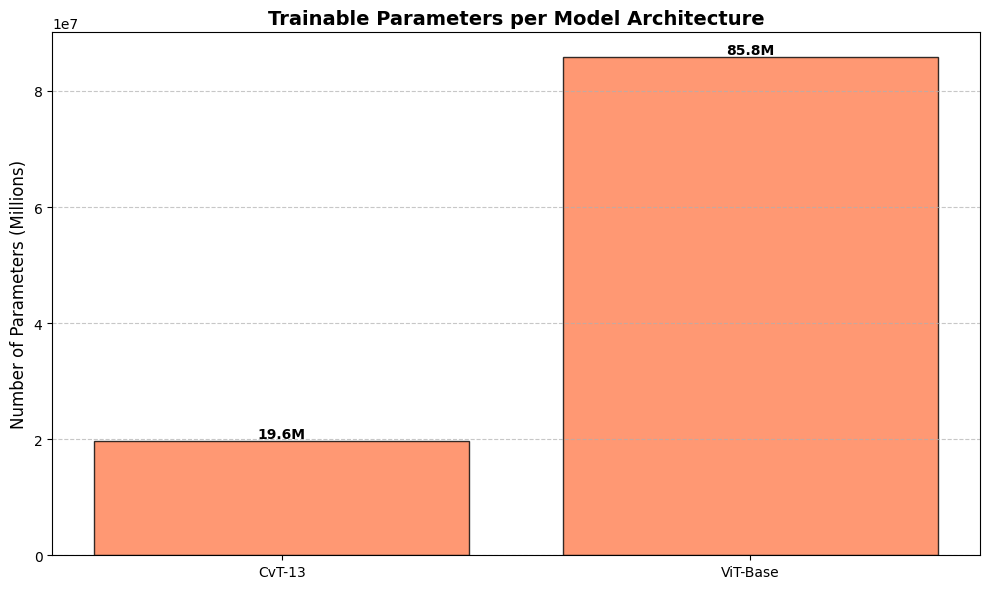

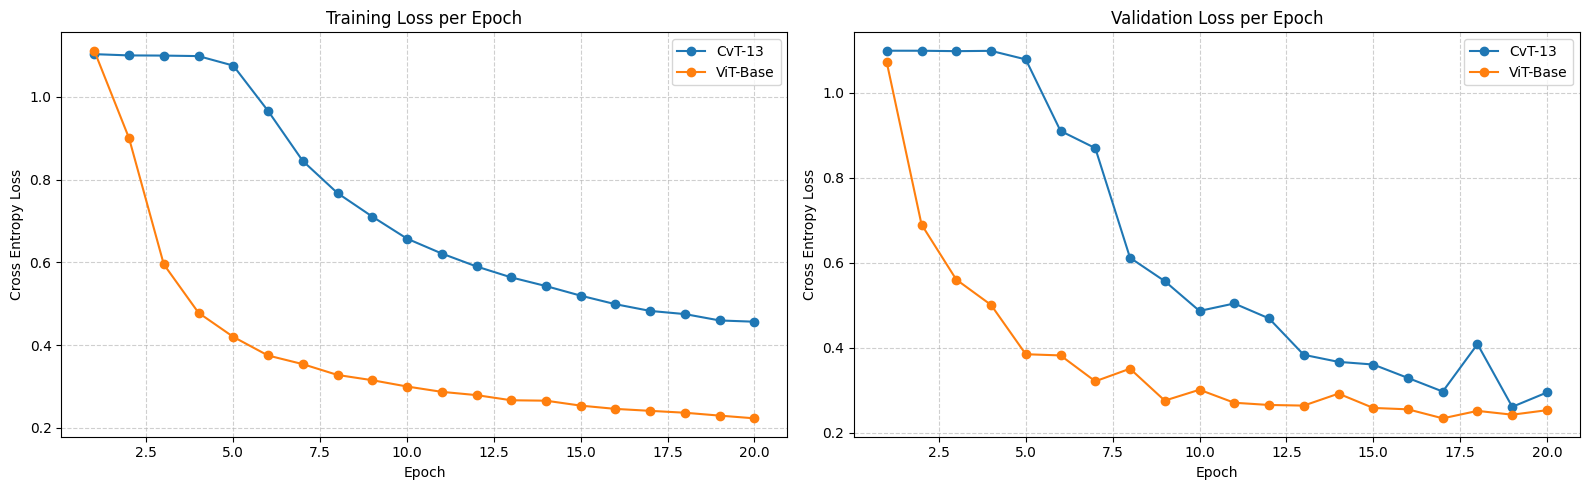

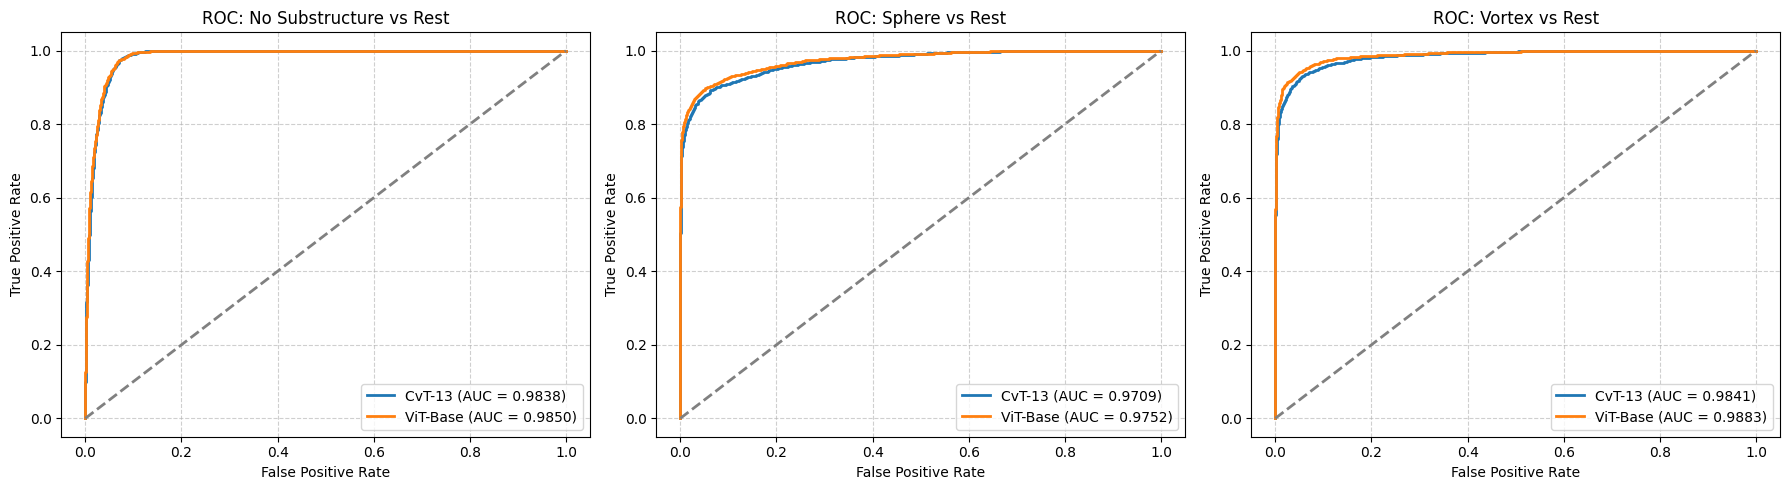

In [12]:
# Tracker no longer needs loaders in its initialization!
master_tracker = ExperimentTracker(num_classes=3)
master_tracker.compare_models(master_configs2, patience=3)

# 4. Generate the Unified Master Plots
print("\nGenerating Unified Master Plots...")
master_tracker.plot_parameter_counts()
master_tracker.plot_loss_curves()
master_tracker.plot_roc_curves()